# 🚫 Absolute Rejection Model
### Domain-specific image filter — retrainable for any project

**How it works:**
1. Upload images from YOUR domain (sports, medical, etc.)
2. Model learns what your domain looks like
3. Any image that doesn't match → **REJECTED**
4. Retrain anytime for a new project

---
> ✅ No labels needed | ✅ Works on any domain | ✅ GPU accelerated

## Cell 1 — Install Dependencies

In [1]:
!pip install -q scikit-learn tqdm Pillow torch torchvision
print('✅ All dependencies installed')

✅ All dependencies installed


## Cell 2 — Imports & Setup

In [2]:
import os, pickle, warnings, zipfile, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import files

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')

SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}

IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

✅ Using device: cuda


## Cell 3 — Define Feature Extractor & Rejection Model

In [3]:
# ──────────────────────────────────────────
# FEATURE EXTRACTOR (ResNet50, frozen)
# ──────────────────────────────────────────
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-1])

    def forward(self, x):
        with torch.no_grad():
            feat = self.features(x)
            feat = feat.squeeze(-1).squeeze(-1)
        return feat


def load_extractor():
    model = FeatureExtractor().to(DEVICE)
    model.eval()
    return model


def extract_features(image_paths, extractor, batch_size=32):
    all_features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc='Extracting features'):
        batch_paths = image_paths[i:i+batch_size]
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert('RGB')
                tensor = IMAGE_TRANSFORM(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f'  [SKIP] {path}: {e}')
        if not batch_tensors:
            continue
        batch = torch.stack(batch_tensors).to(DEVICE)
        feats = extractor(batch).cpu().numpy()
        all_features.append(feats)
    return np.vstack(all_features)


def get_image_paths(directory):
    paths = []
    for root, _, files_list in os.walk(directory):
        for f in files_list:
            if os.path.splitext(f)[1].lower() in SUPPORTED_EXTENSIONS:
                paths.append(os.path.join(root, f))
    return sorted(paths)


# ──────────────────────────────────────────
# REJECTION MODEL (Dual-gate OOD detector)
# ──────────────────────────────────────────
class RejectionModel:
    """
    Gate 1 — IsolationForest  : general anomaly detection
    Gate 2 — Mahalanobis dist : distance from training cluster center
    BOTH must pass → ACCEPT. Either fails → REJECT.
    """
    def __init__(self, contamination=0.05, pca_components=128, mahal_threshold_percentile=99):
        self.contamination = contamination
        self.pca_components = pca_components
        self.mahal_threshold_percentile = mahal_threshold_percentile
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=pca_components, random_state=42)
        self.iso_forest = IsolationForest(
            n_estimators=200, contamination=contamination,
            random_state=42, n_jobs=-1)
        self.mean = None
        self.cov_inv = None
        self.mahal_threshold = None
        self.is_trained = False

    def fit(self, features):
        print(f'\n[TRAIN] Fitting on {len(features)} images...')
        feats_scaled = self.scaler.fit_transform(features)
        feats_pca = self.pca.fit_transform(feats_scaled)
        print(f'  PCA variance explained: {self.pca.explained_variance_ratio_.sum()*100:.1f}%')
        self.iso_forest.fit(feats_pca)
        self.mean = np.mean(feats_pca, axis=0)
        cov = np.cov(feats_pca, rowvar=False) + np.eye(feats_pca.shape[1]) * 1e-5
        self.cov_inv = np.linalg.inv(cov)
        train_distances = self._mahal_distances(feats_pca)
        self.mahal_threshold = np.percentile(train_distances, self.mahal_threshold_percentile)
        print(f'  Mahalanobis threshold (p{self.mahal_threshold_percentile}): {self.mahal_threshold:.2f}')
        self.is_trained = True
        print('[TRAIN] Done!\n')

    def _mahal_distances(self, feats_pca):
        diff = feats_pca - self.mean
        left = diff @ self.cov_inv
        return np.sqrt(np.einsum('ij,ij->i', left, diff))

    def predict(self, features):
        assert self.is_trained, 'Train the model first!'
        feats_scaled = self.scaler.transform(features)
        feats_pca = self.pca.transform(feats_scaled)
        iso_preds = self.iso_forest.predict(feats_pca)
        iso_scores = self.iso_forest.score_samples(feats_pca)
        mahal_dists = self._mahal_distances(feats_pca)
        decisions, details = [], []
        for i in range(len(features)):
            iso_ok = (iso_preds[i] == 1)
            mahal_ok = (mahal_dists[i] <= self.mahal_threshold)
            accepted = iso_ok and mahal_ok
            decisions.append('ACCEPT' if accepted else 'REJECT')
            details.append({
                'iso_score': round(float(iso_scores[i]), 4),
                'iso_gate': 'PASS' if iso_ok else 'FAIL',
                'mahal_distance': round(float(mahal_dists[i]), 2),
                'mahal_gate': 'PASS' if mahal_ok else 'FAIL',
                'decision': 'ACCEPT' if accepted else 'REJECT'
            })
        return decisions, details

    def save(self, path='rejection_model.pkl'):
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f'[SAVE] Model saved → {path}')

    @staticmethod
    def load(path='rejection_model.pkl'):
        with open(path, 'rb') as f:
            m = pickle.load(f)
        print(f'[LOAD] Model loaded ← {path}')
        return m


print('✅ All classes defined.')

✅ All classes defined.


## Cell 4 — Upload Training Images
> Upload a **ZIP file** containing your domain images (e.g. `sports.zip`)  
> The zip should contain images directly or in subfolders.

📁 Upload your training images ZIP file...


Saving train.zip to train.zip
✅ Extracted train.zip → /content/train_images

📊 Total training images found: 270


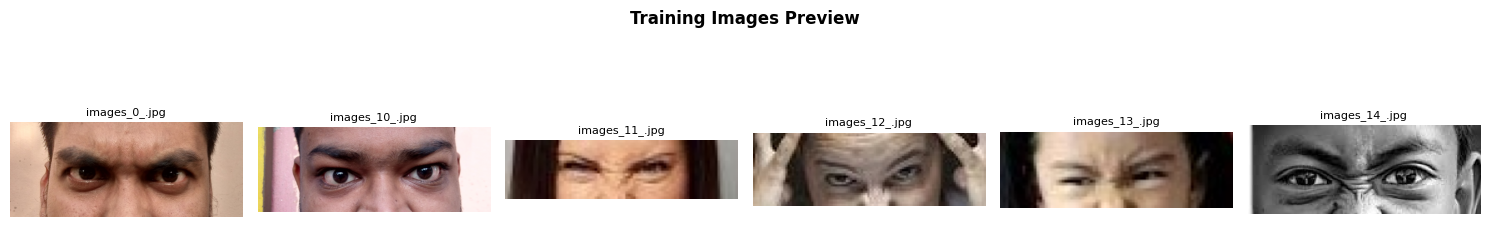

In [4]:
TRAIN_DIR = '/content/train_images'
os.makedirs(TRAIN_DIR, exist_ok=True)

print('📁 Upload your training images ZIP file...')
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(TRAIN_DIR)
        print(f'✅ Extracted {fname} → {TRAIN_DIR}')
    else:
        # Single image or non-zip: move to train dir
        shutil.copy(fname, os.path.join(TRAIN_DIR, fname))
        print(f'✅ Copied {fname} → {TRAIN_DIR}')

train_paths = get_image_paths(TRAIN_DIR)
print(f'\n📊 Total training images found: {len(train_paths)}')

# Preview a few training images
preview = train_paths[:min(6, len(train_paths))]
fig, axes = plt.subplots(1, len(preview), figsize=(15, 3))
if len(preview) == 1:
    axes = [axes]
for ax, p in zip(axes, preview):
    img = Image.open(p).convert('RGB')
    ax.imshow(img)
    ax.set_title(os.path.basename(p)[:15], fontsize=8)
    ax.axis('off')
plt.suptitle('Training Images Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 5 — Train the Rejection Model
> Tune the parameters below if needed

In [5]:
# ── TUNE THESE ──────────────────────────────────────────────
CONTAMINATION = 0.05      # Expected outlier % in training data (0.01–0.1)
                           # Lower = stricter rejection
PCA_COMPONENTS = 128      # Feature compression (64–256)
THRESHOLD_PERCENTILE = 99 # Mahalanobis cutoff (95–99.9). Higher = stricter
BATCH_SIZE = 32
MODEL_SAVE_PATH = '/content/rejection_model.pkl'
# ─────────────────────────────────────────────────────────────

print('🔧 Loading feature extractor (ResNet50)...')
extractor = load_extractor()

print('🔍 Extracting features from training images...')
train_features = extract_features(train_paths, extractor, batch_size=BATCH_SIZE)
print(f'   Feature matrix shape: {train_features.shape}')

print('\n🏋️ Training rejection model...')
rejection_model = RejectionModel(
    contamination=CONTAMINATION,
    pca_components=PCA_COMPONENTS,
    mahal_threshold_percentile=THRESHOLD_PERCENTILE
)
rejection_model.fit(train_features)
rejection_model.save(MODEL_SAVE_PATH)

# Sanity check — run model on training data itself
decisions, _ = rejection_model.predict(train_features)
accepted = decisions.count('ACCEPT')
rejected = decisions.count('REJECT')
print(f'\n📊 Sanity check on training data:')
print(f'   ✅ Accepted: {accepted} / {len(decisions)} ({accepted/len(decisions)*100:.1f}%)')
print(f'   ❌ Rejected: {rejected} / {len(decisions)} ({rejected/len(decisions)*100:.1f}%)')
print('\n✅ Model ready! Proceed to test images.')

🔧 Loading feature extractor (ResNet50)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


🔍 Extracting features from training images...


Extracting features: 100%|██████████| 9/9 [00:03<00:00,  2.74it/s]


   Feature matrix shape: (270, 2048)

🏋️ Training rejection model...

[TRAIN] Fitting on 270 images...
  PCA variance explained: 86.5%
  Mahalanobis threshold (p99): 16.25
[TRAIN] Done!

[SAVE] Model saved → /content/rejection_model.pkl

📊 Sanity check on training data:
   ✅ Accepted: 253 / 270 (93.7%)
   ❌ Rejected: 17 / 270 (6.3%)

✅ Model ready! Proceed to test images.


## Cell 6 — Test: Upload Images to Filter
> Upload a **ZIP** of test images (mix of in-domain and out-of-domain).  
> The model will show which are accepted and which are rejected.

In [6]:
TEST_DIR = '/content/test_images'
os.makedirs(TEST_DIR, exist_ok=True)

print('📁 Upload your test images ZIP file (mix of any images)...')
uploaded_test = files.upload()

for fname in uploaded_test:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(TEST_DIR)
        print(f'✅ Extracted {fname} → {TEST_DIR}')
    else:
        shutil.copy(fname, os.path.join(TEST_DIR, fname))
        print(f'✅ Copied {fname} → {TEST_DIR}')

test_paths = get_image_paths(TEST_DIR)
print(f'\n📊 Total test images found: {len(test_paths)}')

📁 Upload your test images ZIP file (mix of any images)...


Saving test.zip to test.zip
✅ Extracted test.zip → /content/test_images

📊 Total test images found: 138


## Cell 7 — Run Rejection & Visualize Results

🔍 Extracting features from test images...


Extracting features: 100%|██████████| 5/5 [00:01<00:00,  3.60it/s]


🚦 Running rejection model...

──────────────────────────────────────────────────
  RESULTS
──────────────────────────────────────────────────
  Total   : 138
  ✅ Accepted : 137  (99.3%)
  ❌ Rejected : 1  (0.7%)


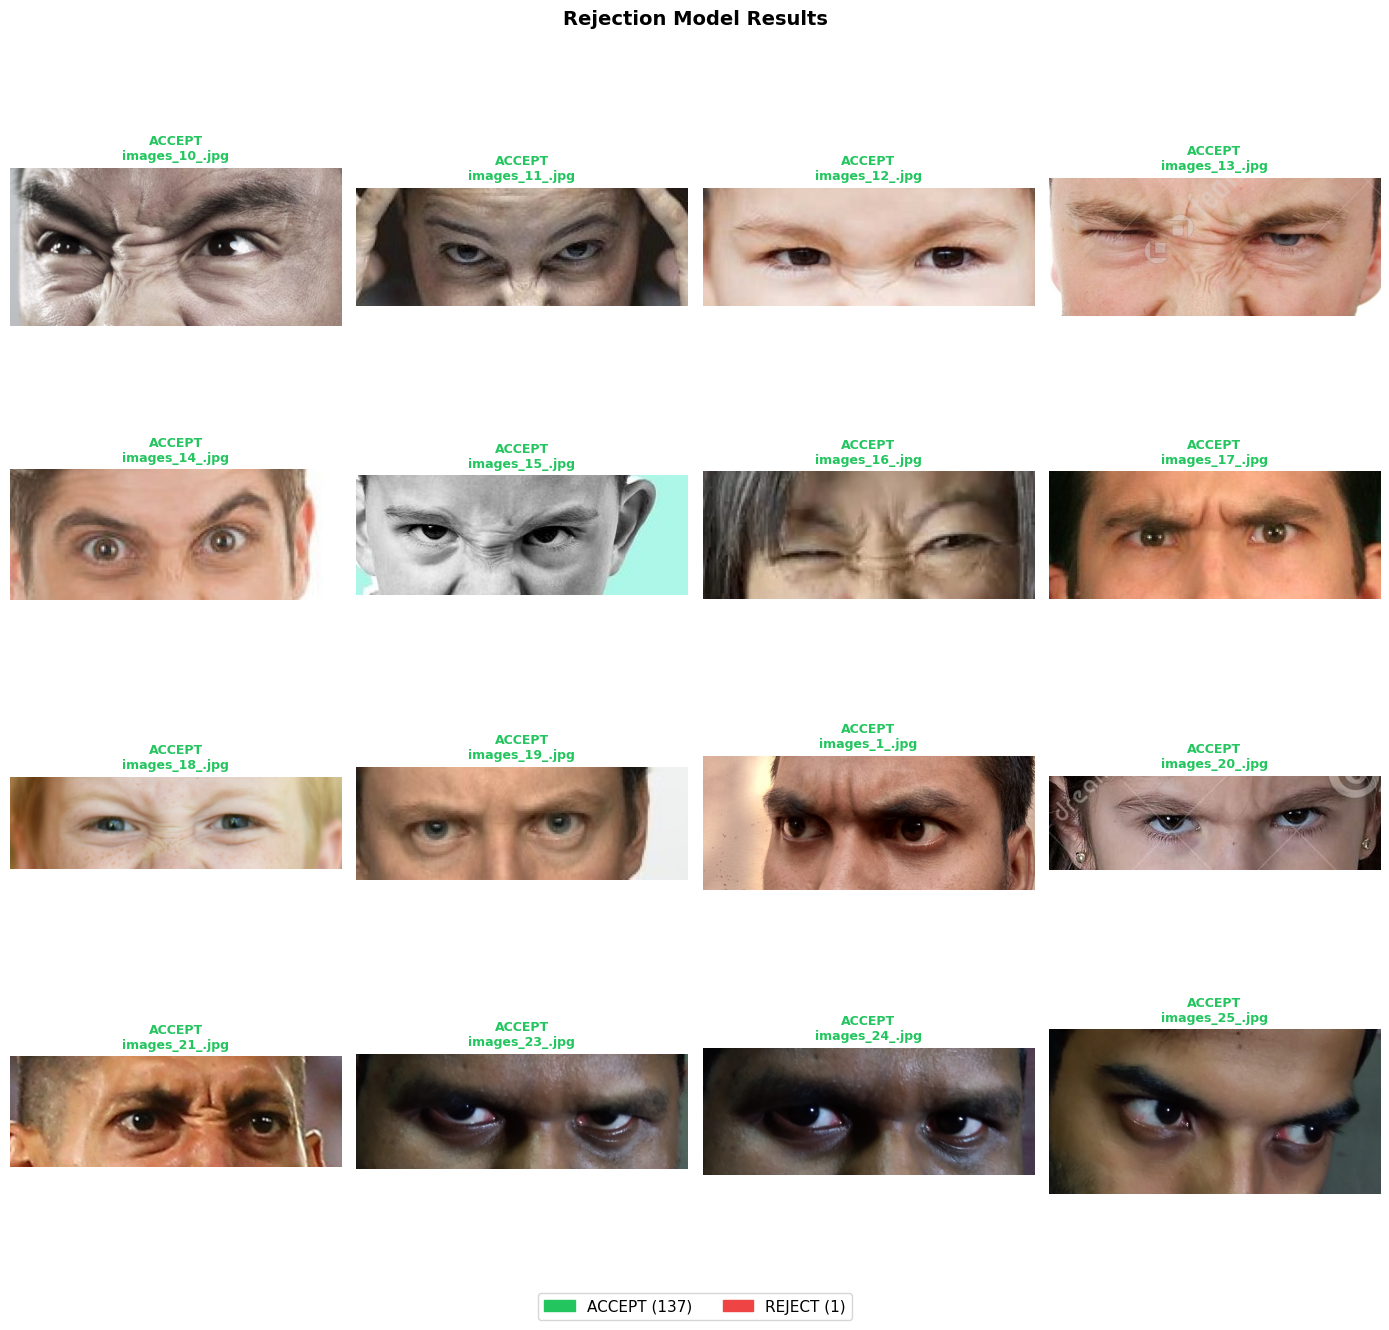

In [7]:
# ── Safety: reinitialize extractor & model if session was reset ──
if 'extractor' not in dir() or extractor is None:
    print('⚠️  extractor not found — reloading ResNet50...')
    extractor = load_extractor()

if 'rejection_model' not in dir() or not hasattr(rejection_model, 'is_trained') or not rejection_model.is_trained:
    print('⚠️  rejection_model not found — loading from saved file...')
    rejection_model = RejectionModel.load(MODEL_SAVE_PATH)

if 'BATCH_SIZE' not in dir():
    BATCH_SIZE = 32

# Extract test features
print('🔍 Extracting features from test images...')
test_features = extract_features(test_paths, extractor, batch_size=BATCH_SIZE)

# Run rejection
print('🚦 Running rejection model...')
decisions, details = rejection_model.predict(test_features)

accepted_paths = [p for p, d in zip(test_paths, decisions) if d == 'ACCEPT']
rejected_paths = [p for p, d in zip(test_paths, decisions) if d == 'REJECT']

sep = '─'*50
print(f'\n{sep}')
print('  RESULTS')
print(f'{sep}')
print(f'  Total   : {len(test_paths)}')
print(f'  ✅ Accepted : {len(accepted_paths)}  ({len(accepted_paths)/len(test_paths)*100:.1f}%)')
print(f'  ❌ Rejected : {len(rejected_paths)}  ({len(rejected_paths)/len(test_paths)*100:.1f}%)')

# ── VISUALIZATION ──────────────────────────────────────────
all_paths = accepted_paths + rejected_paths
all_labels = ['ACCEPT'] * len(accepted_paths) + ['REJECT'] * len(rejected_paths)

n = min(16, len(all_paths))
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.2))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for i, ax in enumerate(axes):
    if i < n:
        path = all_paths[i]
        label = all_labels[i]
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        color = '#22c55e' if label == 'ACCEPT' else '#ef4444'
        ax.set_title(f'{label}\n{os.path.basename(path)[:18]}',
                     color=color, fontsize=9, fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
    ax.axis('off')

green_patch = mpatches.Patch(color='#22c55e', label=f'ACCEPT ({len(accepted_paths)})')
red_patch   = mpatches.Patch(color='#ef4444', label=f'REJECT ({len(rejected_paths)})')
fig.legend(handles=[green_patch, red_patch], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Rejection Model Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Cell 8 — Detailed Per-Image Report

In [8]:
if 'decisions' not in dir() or 'details' not in dir():
    raise RuntimeError('⚠️  Run Cell 7 first to generate decisions and details.')

print(f"{'Image':<35} {'Decision':<10} {'ISO Gate':<10} {'ISO Score':<12} {'Mahal Dist':<12} {'Mahal Gate'}")
print('─' * 95)

for path, decision, detail in zip(test_paths, decisions, details):
    name = os.path.basename(path)[:33]
    icon = '✅' if decision == 'ACCEPT' else '❌'
    print(f"{name:<35} {icon} {decision:<8} {detail['iso_gate']:<10} "
          f"{detail['iso_score']:<12} {detail['mahal_distance']:<12} {detail['mahal_gate']}")

# Save CSV
csv_path = '/content/rejection_results.csv'
with open(csv_path, 'w') as f:
    f.write('image,decision,iso_score,iso_gate,mahal_distance,mahal_gate\n')
    for path, decision, detail in zip(test_paths, decisions, details):
        f.write(f"{path},{decision},{detail['iso_score']},{detail['iso_gate']},"
                f"{detail['mahal_distance']},{detail['mahal_gate']}\n")
print(f'\n📄 Results saved to CSV → {csv_path}')

Image                               Decision   ISO Gate   ISO Score    Mahal Dist   Mahal Gate
───────────────────────────────────────────────────────────────────────────────────────────────
images_10_.jpg                      ✅ ACCEPT   PASS       -0.3624      7.87         PASS
images_11_.jpg                      ✅ ACCEPT   PASS       -0.3915      11.07        PASS
images_12_.jpg                      ✅ ACCEPT   PASS       -0.3367      3.62         PASS
images_13_.jpg                      ✅ ACCEPT   PASS       -0.3544      6.29         PASS
images_14_.jpg                      ✅ ACCEPT   PASS       -0.3344      3.18         PASS
images_15_.jpg                      ✅ ACCEPT   PASS       -0.3683      8.33         PASS
images_16_.jpg                      ✅ ACCEPT   PASS       -0.3589      7.3          PASS
images_17_.jpg                      ✅ ACCEPT   PASS       -0.341       4.47         PASS
images_18_.jpg                      ✅ ACCEPT   PASS       -0.3577      7.27         PASS
images_1

## Cell 9 — Download Results & Model

In [9]:
print('⬇️ Downloading CSV results...')
files.download('/content/rejection_results.csv')

print('⬇️ Downloading trained model (.pkl)...')
files.download('/content/rejection_model.pkl')

print('✅ Done! Save the .pkl file — reload it anytime without retraining.')

⬇️ Downloading CSV results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading trained model (.pkl)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! Save the .pkl file — reload it anytime without retraining.


## Cell 10 — (Optional) Reload Saved Model & Test a Single Image

[LOAD] Model loaded ← /content/rejection_model.pkl

📁 Upload one image to test...


Saving abstract-geometric-background-shapes-texture_1194-306781.avif to abstract-geometric-background-shapes-texture_1194-306781.avif


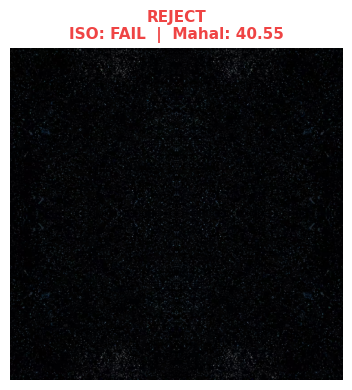


  Decision        : REJECT
  IsolationForest : score=-0.6192  gate=FAIL
  Mahalanobis     : dist=40.55  gate=FAIL  threshold=16.25


In [64]:


loaded_model = RejectionModel.load('/content/rejection_model.pkl')

# Upload one image to test
print('\n📁 Upload one image to test...')
uploaded_img = files.upload()
img_name = list(uploaded_img.keys())[0]

extractor = load_extractor()
img = Image.open(img_name).convert('RGB')
tensor = IMAGE_TRANSFORM(img).unsqueeze(0).to(DEVICE)
feat = extractor(tensor).cpu().numpy()

decisions_single, details_single = loaded_model.predict(feat)
d = details_single[0]

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img)
color = '#22c55e' if decisions_single[0] == 'ACCEPT' else '#ef4444'
ax.set_title(f"{decisions_single[0]}\nISO: {d['iso_gate']}  |  Mahal: {d['mahal_distance']}",
             color=color, fontsize=11, fontweight='bold')
for spine in ax.spines.values():
    spine.set_edgecolor(color)
    spine.set_linewidth(4)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\n  Decision        : {decisions_single[0]}")
print(f"  IsolationForest : score={d['iso_score']}  gate={d['iso_gate']}")
print(f"  Mahalanobis     : dist={d['mahal_distance']}  gate={d['mahal_gate']}  threshold={loaded_model.mahal_threshold:.2f}")

✅ Total successful images: 2



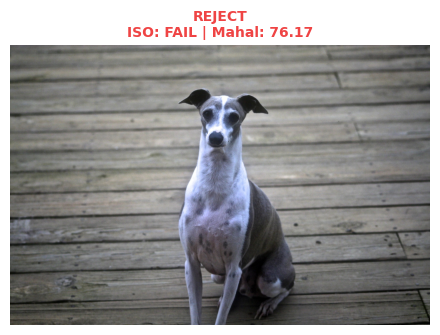

Index    : 2
Decision : REJECT
Path     : /content/rejection_web_test_1000/rejected/0002_Louie_the_Italian_Greyhound_.jpg.jpg
------------------------------------------------------------


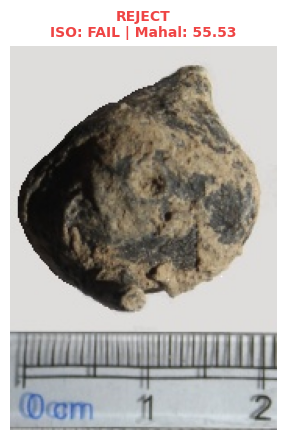

Index    : 980
Decision : REJECT
Path     : /content/rejection_web_test_1000/rejected/0980_Avicenna_sp._fruit_Acanthaceae_London_Clay_pyrite_fossil_by_Omar_Hoftun.png.jpg
------------------------------------------------------------


In [58]:
# ==========================================
# DISPLAY ONLY SUCCESSFUL IMAGES
# ==========================================

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

CSV_PATH = "/content/rejection_web_test_1000/web_image_test_results_1000.csv"

df = pd.read_csv(CSV_PATH)

# filter only success
df_success = df[df["status"] == "SUCCESS"]

print(f"✅ Total successful images: {len(df_success)}\n")

if len(df_success) == 0:
    print("⚠ No successful images to display")
else:
    for idx, row in df_success.iterrows():
        try:
            img = Image.open(row["saved_image_path"]).convert("RGB")

            fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
            ax.imshow(img)

            color = "#22c55e" if row["decision"] == "ACCEPT" else "#ef4444"

            ax.set_title(
                f"{row['decision']}\nISO: {row['iso_gate']} | Mahal: {row['mahal_distance']}",
                color=color,
                fontsize=10,
                fontweight='bold'
            )

            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(4)

            ax.axis('off')
            plt.tight_layout()
            plt.show()

            print(f"Index    : {row['index']}")
            print(f"Decision : {row['decision']}")
            print(f"Path     : {row['saved_image_path']}")
            print("-" * 60)

        except Exception as e:
            print(f"❌ Error displaying image: {e}")

## Cell 11 — Retrain for a New Project
> Just upload new domain images and run. Old model is replaced.